<h1 style="text-align:center; color:#1f4e79; font-size:40px;">
Railway Riders Travel Analysis
</h1>

UK Railway Travel Analysis is a Python-based dataproject using mock National Rail ticket data from January to April 2024.
The project explores railway travel patterns, ticket sales, pricing, revenue, routes, and service performance.
    
### The analysis focuses on:
    
* Identifying the most popular travel routes.
* Analysing peak travel times.
* Comparing revenue by ticket type and class.
* Evaluating ticket prices and journey patterns.
* Analysing on-time vs. delayed journeys.
* Identifying factors that may contribute to train delays.
* Creating visualisations to communicate key findings and trends.

# Column Description

* Transaction ID-Unique identifier for each train ticket purchase.

* Date of Purchase-Date when the ticket was purchased.

* Time of Purchase-Time when the ticket was purchased.

* Purchase Type-Indicates whether the ticket was purchased online or at a train station.

* Payment Method-Method used to purchase the ticket, such as Contactless, Credit Card, or Debit Card.

* Railcard-Indicates whether the passenger has a Railcard and the type of Railcard.

* Ticket Class-Class of the ticket, such as Standard or First.

* Ticket Type-Type of ticket, such as Advance, Off-Peak, or Anytime.

* Price-Final cost of the ticket.

* Departure Station-Station where the passenger boards the train.

* Arrival Destination-Station where the passenger exits the train.

* Date of Journey-Date on which the train journey takes place.

* Departure Time-Time when the train departs from the departure station.

* Arrival Time-Scheduled time when the train is expected to arrive.

* Actual Arrival Time-Actual time when the train arrives at the destination.

* Journey Status-Indicates whether the journey was on time, delayed, or cancelled.

* Reason for Delay-Reason for the train delay or cancellation.

* Refund Request-Indicates whether the passenger requested a refund after a delay or cancellation.

# Raw Data

In [137]:
import pandas as pd
# Load raw data
df = pd.read_csv(r"C:\Users\HP\Documents\railway.csv")

# Preview data
df.head()


,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


# Checking Duplicates

In [138]:
# Check duplicate rows
df.duplicated().sum()

print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Transaction IDs:", df["Transaction ID"].duplicated().sum())

Duplicate rows: 0
Duplicate Transaction IDs: 0


In [139]:
df["Transaction ID"].duplicated().sum()

np.int64(0)

In [140]:
#No duplicate found.

# Changing DataType

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       31653 non-null  object
 1   Date of Purchase     31653 non-null  object
 2   Time of Purchase     31653 non-null  object
 3   Purchase Type        31653 non-null  object
 4   Payment Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket Class         31653 non-null  object
 7   Ticket Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure Station    31653 non-null  object
 10  Arrival Destination  31653 non-null  object
 11  Date of Journey      31653 non-null  object
 12  Departure Time       31653 non-null  object
 13  Arrival Time         31653 non-null  object
 14  Actual Arrival Time  29773 non-null  object
 15  Journey Status       31653 non-null  object
 16  Reas

In [142]:
# Convert date columns
df["Date of Purchase"] = pd.to_datetime(df["Date of Purchase"])
df["Date of Journey"] = pd.to_datetime(df["Date of Journey"])

# Convert time columns
df["Time of Purchase"] = pd.to_datetime(df["Time of Purchase"], format="%H:%M:%S").dt.time
df["Departure Time"] = pd.to_datetime(df["Departure Time"], format="%H:%M:%S").dt.time
df["Arrival Time"] = pd.to_datetime(df["Arrival Time"], format="%H:%M:%S").dt.time

df["Actual Arrival Time"] = pd.to_datetime(df["Actual Arrival Time"], format="%H:%M:%S", errors="coerce").dt.time



In [143]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


In [144]:
# Convert time columns to datetime format

time_columns = [
    "Time of Purchase",
    "Departure Time",
    "Arrival Time",
    "Actual Arrival Time"
]

for col in time_columns:
    df[col] = pd.to_datetime(df[col], format="%H:%M:%S", errors="coerce")

df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,1900-01-01 12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,1900-01-01 11:00:00,1900-01-01 13:30:00,1900-01-01 13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,1900-01-01 11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,1900-01-01 09:45:00,1900-01-01 11:35:00,1900-01-01 11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,1900-01-01 19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,1900-01-01 18:15:00,1900-01-01 18:45:00,1900-01-01 18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,1900-01-01 23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,1900-01-01 21:30:00,1900-01-01 22:30:00,1900-01-01 22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,1900-01-01 18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,1900-01-01 16:45:00,1900-01-01 19:00:00,1900-01-01 19:00:00,On Time,NaN,No


In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       31653 non-null  object        
 1   Date of Purchase     31653 non-null  datetime64[ns]
 2   Time of Purchase     31653 non-null  datetime64[ns]
 3   Purchase Type        31653 non-null  object        
 4   Payment Method       31653 non-null  object        
 5   Railcard             10735 non-null  object        
 6   Ticket Class         31653 non-null  object        
 7   Ticket Type          31653 non-null  object        
 8   Price                31653 non-null  int64         
 9   Departure Station    31653 non-null  object        
 10  Arrival Destination  31653 non-null  object        
 11  Date of Journey      31653 non-null  datetime64[ns]
 12  Departure Time       31653 non-null  datetime64[ns]
 13  Arrival Time         31653 non-

# Checking Null

In [146]:
df.isnull().sum()

Transaction ID             0
Date of Purchase           0
Time of Purchase           0
Purchase Type              0
Payment Method             0
Railcard               20918
Ticket Class               0
Ticket Type                0
Price                      0
Departure Station          0
Arrival Destination        0
Date of Journey            0
Departure Time             0
Arrival Time               0
Actual Arrival Time     1880
Journey Status             0
Reason for Delay       27481
Refund Request             0
dtype: int64

# Filling the Null Value

In [147]:
df["Railcard"] = df["Railcard"].fillna("Not Applicable")

df["Reason for Delay"] = df["Reason for Delay"].fillna("No Delay")

df["Actual Arrival Time"] = df["Actual Arrival Time"].fillna(
    df["Arrival Time"]
)


In [148]:
#Null value against cancelled rides

In [149]:
df["Railcard"].isnull().sum()


np.int64(0)

In [150]:
df["Reason for Delay"].isnull().sum()


np.int64(0)

In [151]:
df["Actual Arrival Time"].isnull().sum()


np.int64(0)

In [152]:
df.isnull().sum()

Transaction ID         0
Date of Purchase       0
Time of Purchase       0
Purchase Type          0
Payment Method         0
Railcard               0
Ticket Class           0
Ticket Type            0
Price                  0
Departure Station      0
Arrival Destination    0
Date of Journey        0
Departure Time         0
Arrival Time           0
Actual Arrival Time    0
Journey Status         0
Reason for Delay       0
Refund Request         0
dtype: int64

In [153]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,1900-01-01 12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,1900-01-01 11:00:00,1900-01-01 13:30:00,1900-01-01 13:30:00,On Time,No Delay,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,1900-01-01 11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,1900-01-01 09:45:00,1900-01-01 11:35:00,1900-01-01 11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,1900-01-01 19:51:27,Online,Credit Card,Not Applicable,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,1900-01-01 18:15:00,1900-01-01 18:45:00,1900-01-01 18:45:00,On Time,No Delay,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,1900-01-01 23:00:36,Station,Credit Card,Not Applicable,Standard,Advance,13,London Paddington,Reading,2024-01-01,1900-01-01 21:30:00,1900-01-01 22:30:00,1900-01-01 22:30:00,On Time,No Delay,No
4,2be00b45-0762-485e-a7a3,2023-12-27,1900-01-01 18:22:56,Online,Contactless,Not Applicable,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,1900-01-01 16:45:00,1900-01-01 19:00:00,1900-01-01 19:00:00,On Time,No Delay,No


# New Column "Month of Travel"

In [154]:
# Create Month column from Date of Journey
df["Month of Travel"] = df["Date of Journey"].dt.month_name()

df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Month of Travel
0,da8a6ba8-b3dc-4677-b176,2023-12-08,1900-01-01 12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,1900-01-01 11:00:00,1900-01-01 13:30:00,1900-01-01 13:30:00,On Time,No Delay,No,January
1,b0cdd1b0-f214-4197-be53,2023-12-16,1900-01-01 11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,1900-01-01 09:45:00,1900-01-01 11:35:00,1900-01-01 11:40:00,Delayed,Signal Failure,No,January
2,f3ba7a96-f713-40d9-9629,2023-12-19,1900-01-01 19:51:27,Online,Credit Card,Not Applicable,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,1900-01-01 18:15:00,1900-01-01 18:45:00,1900-01-01 18:45:00,On Time,No Delay,No,January
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,1900-01-01 23:00:36,Station,Credit Card,Not Applicable,Standard,Advance,13,London Paddington,Reading,2024-01-01,1900-01-01 21:30:00,1900-01-01 22:30:00,1900-01-01 22:30:00,On Time,No Delay,No,January
4,2be00b45-0762-485e-a7a3,2023-12-27,1900-01-01 18:22:56,Online,Contactless,Not Applicable,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,1900-01-01 16:45:00,1900-01-01 19:00:00,1900-01-01 19:00:00,On Time,No Delay,No,January


# Checking Inconsistency in Data

In [155]:
# Check unique values in categorical columns

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 Transaction ID
Transaction ID
da8a6ba8-b3dc-4677-b176    1
57270295-4c04-41ef-8d60    1
e69c5905-c982-4362-8413    1
79d56b17-19ee-4f2d-a279    1
7dbec16c-8f83-442c-a7a2    1
                          ..
0bbcdb6e-1da7-4e88-9ddd    1
625339b0-33be-45b7-acf8    1
2829b4fd-802d-480f-8346    1
b8d53a45-b49b-453b-81b4    1
1d5d89a2-bde5-410f-8f91    1
Name: count, Length: 31653, dtype: int64

 Purchase Type
Purchase Type
Online     18521
Station    13132
Name: count, dtype: int64

 Payment Method
Payment Method
Credit Card    19136
Contactless    10834
Debit Card      1683
Name: count, dtype: int64

 Railcard
Railcard
Not Applicable    20918
Adult              4846
Disabled           3089
Senior             2800
Name: count, dtype: int64

 Ticket Class
Ticket Class
Standard       28595
First Class     3058
Name: count, dtype: int64

 Ticket Type
Ticket Type
Advance     17561
Off-Peak     8752
Anytime      5340
Name: count, dtype: int64

 Departure Station
Departure Station
Manchester Picc

In [156]:
# Combine Signal Failure with Singal Failure

df.loc[df["Reason for Delay"] =="Signal failure" , "Reason for Delay"] = "Signal Failure"

df["Reason for Delay"].value_counts()

# Change Weather Conditions to Weather

df["Reason for Delay"] = df["Reason for Delay"].replace(
    "Weather Conditions", "Weather"
)

df["Reason for Delay"].value_counts()

# Combine Staffing with Staff Shortage

df["Reason for Delay"] = df["Reason for Delay"].replace(
    "Staffing", "Staff Shortage"
)

df["Reason for Delay"].value_counts()

Reason for Delay
No Delay           27481
Weather             1372
Signal Failure       970
Staff Shortage       809
Technical Issue      707
Traffic              314
Name: count, dtype: int64

# Outlier Checking for Price

In [157]:
df[["Price"]].describe()

,Price
count,31653.000000
mean,23.439200
std,29.997628
min,1.000000
25%,5.000000
50%,11.000000
75%,35.000000
max,267.000000


In [158]:
# Find outliers in numerical columns

numerical_columns = df.select_dtypes(include="number").columns

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, ":", len(outliers), "outliers")
    print(outliers[[col]])


Price : 1555 outliers
       Price
25        86
45       134
51       151
61       134
68       151
...      ...
31607    203
31626    151
31637    101
31639    144
31641     95

[1555 rows x 1 columns]


In [159]:
# Delete Price outliers

Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Price"] >= lower) & (df["Price"] <= upper)]

df[["Price"]].describe()


,Price
count,30098.000000
mean,18.404811
std,19.489431
min,1.000000
25%,5.000000
50%,10.000000
75%,25.000000
max,80.000000


In [160]:
# Count total tickets purchased After outlier deletion

total_tickets = df["Transaction ID"].count()
print("Total tickets purchased:", total_tickets)

Total tickets purchased: 30098


# Analysing the Data

In [161]:
# Count tickets purchased in each month

month_order = ["January", "February", "March", "April"]

df["Month of Travel"].value_counts().reindex(month_order)

Month of Travel
January     7649
February    7397
March       7694
April       7358
Name: count, dtype: int64

In [162]:
# March has highest No of Ticket Purchased.

In [163]:
# Count tickets purchased in 2023 and 2024

df["Purchase Year"] = df["Date of Purchase"].dt.year 
df["Purchase Year"].value_counts().sort_index()


Purchase Year
2023       33
2024    30065
Name: count, dtype: int64

In [164]:
#Most of the ticket Purchased in 2024.

In [165]:
# Average tickets purchased per day

daily_tickets = df.groupby("Date of Purchase")["Transaction ID"].count()

average_tickets_per_day = daily_tickets.mean()

print("Average tickets purchased per day:", average_tickets_per_day)

Average tickets purchased per day: 235.140625


In [166]:
# Ticket purchase location and payment method

print("Purchase Type:")
print(df["Purchase Type"].value_counts())

print("\nPayment Method:")
print(df["Payment Method"].value_counts())

Purchase Type:
Purchase Type
Online     17941
Station    12157
Name: count, dtype: int64

Payment Method:
Payment Method
Credit Card    18045
Contactless    10559
Debit Card      1494
Name: count, dtype: int64


In [167]:
#Most of the ticket Purchased through Online.
#Most common Payment Method is Credit Card

In [168]:
# Count departure stations and arrival destinations

print("Number of departure stations:", df["Departure Station"].nunique())
print("Number of arrival destinations:", df["Arrival Destination"].nunique())

Number of departure stations: 12
Number of arrival destinations: 32


In [169]:
# Count total unique train routes

total_routes = df[["Departure Station", "Arrival Destination"]].drop_duplicates().shape[0]

print("Total routes:", total_routes)

Total routes: 63


In [170]:
# Find the most and least plied routes

route_counts = (
    df.groupby(["Departure Station", "Arrival Destination"])
      .size()
      .sort_values(ascending=False)
)

print("Most plied route:")
print(route_counts.head(1))

print("\nLeast plied route:")
print(route_counts.tail(1))


Most plied route:
Departure Station      Arrival Destination  
Manchester Piccadilly  Liverpool Lime Street    4628
dtype: int64

Least plied route:
Departure Station      Arrival Destination
Manchester Piccadilly  London Kings Cross     6
dtype: int64


In [171]:
# Count successful, delayed and cancelled rides

print("Successful (On Time):", (df["Journey Status"] == "On Time").sum())
print("Delayed:", (df["Journey Status"] == "Delayed").sum())
print("Cancelled:", (df["Journey Status"] == "Cancelled").sum())

Successful (On Time): 26606
Delayed: 1690
Cancelled: 1802


In [172]:
# Percentage of successful rides that were on time or delayed

successful = df[df["Journey Status"].isin(["On Time", "Delayed"])]

percentage = successful["Journey Status"].value_counts(normalize=True) * 100

print(percentage)


Journey Status
On Time    94.027424
Delayed     5.972576
Name: proportion, dtype: float64


In [173]:
# Calculate percentage of cancelled rides

cancelled_percentage = (
    (df["Journey Status"] == "Cancelled").sum()
    / len(df)
) * 100

print("Percentage of cancelled rides:", cancelled_percentage)

Percentage of cancelled rides: 5.987108777991893


In [174]:
# Calculate delay time for delayed journeys only

delayed = df[df["Journey Status"] == "Delayed"].copy()

delayed["Delay Time"] = (
    pd.to_datetime(delayed["Actual Arrival Time"].astype(str))
    - pd.to_datetime(delayed["Arrival Time"].astype(str))
).dt.total_seconds() / 60

# Keep only actual delays
delayed = delayed[delayed["Delay Time"] > 0]

print("Minimum delay:", delayed["Delay Time"].min(), "minutes")
print("Maximum delay:", delayed["Delay Time"].max(), "minutes")
print("Average delay:", delayed["Delay Time"].mean(), "minutes")


Minimum delay: 1.0 minutes
Maximum delay: 180.0 minutes
Average delay: 45.59369422962522 minutes


In [175]:
# Reasons for delayed and cancelled rides

print("Reasons for Delayed Rides:")
print(df[df["Journey Status"] == "Delayed"]["Reason for Delay"].value_counts())

print("\nReasons for Cancelled Rides:")
print(df[df["Journey Status"] == "Cancelled"]["Reason for Delay"].value_counts())

Reasons for Delayed Rides:
Reason for Delay
Weather            498
Signal Failure     429
Technical Issue    395
Staff Shortage     292
Traffic             76
Name: count, dtype: int64

Reasons for Cancelled Rides:
Reason for Delay
Signal Failure     492
Staff Shortage     432
Weather            427
Technical Issue    229
Traffic            222
Name: count, dtype: int64


In [176]:
#Top Reason for Delay is Weather.
#Top Reason for Cancellation is Signal Failure.

In [177]:
# Count delayed rides in each month

df["Month"] = df["Date of Journey"].dt.month_name()

delayed_by_month = (
    df[df["Journey Status"] == "Delayed"]["Month"]
    .value_counts()
    .reindex(["January", "February", "March", "April"])
)

print(delayed_by_month)


Month
January     381
February    444
March       473
April       392
Name: count, dtype: int64


In [178]:
#Most delay occured in March.

In [179]:
# Find the most common delay reason in each month of travel

delayed = df[df["Journey Status"] == "Delayed"]

most_delays = (
    delayed.groupby(["Month of Travel", "Reason for Delay"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Month of Travel", "Count"], ascending=[True, False])
    .drop_duplicates("Month of Travel")
)

print(most_delays)



   Month of Travel Reason for Delay  Count
4            April          Weather    126
9         February          Weather    165
10         January   Signal Failure    107
15           March   Signal Failure    131


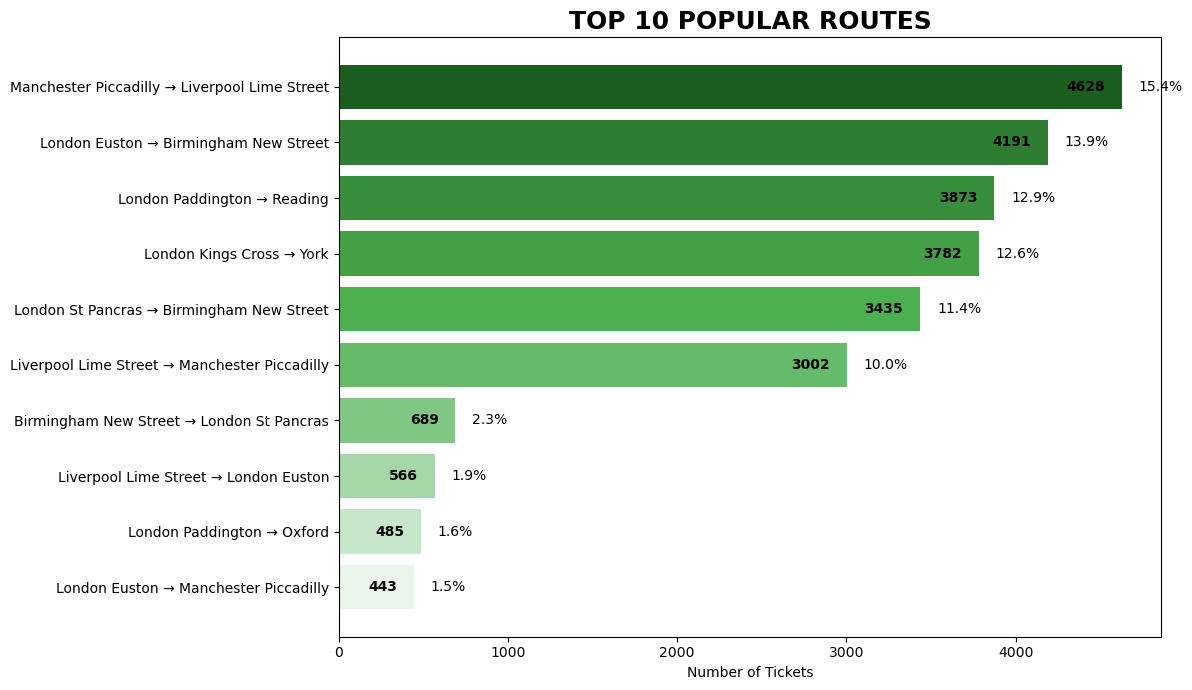

In [180]:
# Top 10 popular routes with ticket count and percentage

import matplotlib.pyplot as plt

route_counts = (
    df.groupby(["Departure Station", "Arrival Destination"])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

routes = [
    f"{departure} → {arrival}"
    for departure, arrival in route_counts.index
]

counts = route_counts.values
percentages = (counts / len(df)) * 100

colors = ["#E8F5E9",
    "#C8E6C9",
    "#A5D6A7",
    "#81C784",
    "#66BB6A",
    "#4CAF50",
    "#43A047",
    "#388E3C",
    "#2E7D32",
    "#1B5E20"
    
]

plt.figure(figsize=(12, 7))


bars = plt.barh(routes[::-1], counts[::-1] ,color=colors)

plt.title("TOP 10 POPULAR ROUTES", fontsize=18, fontweight="bold")
plt.xlabel("Number of Tickets")
plt.ylabel("")

# Add ticket count and percentage
for bar, count, percentage in zip(bars, counts[::-1], percentages[::-1]):
    plt.text(
        bar.get_width() - 100,
        bar.get_y() + bar.get_height()/2,
        f"{count}",
        va="center",
        ha="right",
        fontweight="bold"
    )
    
    plt.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height()/2,
        f"{percentage:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()


In [181]:
#Shows the 10 top Travelled routes and no of times trav

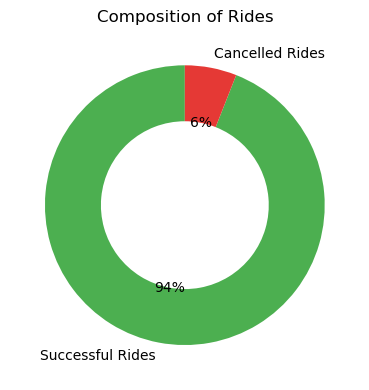

In [182]:
# Composition of Rides

status_counts = df["Journey Status"].value_counts()

successful = status_counts.get("On Time", 0) + status_counts.get("Delayed", 0)
cancelled = status_counts.get("Cancelled", 0)

labels = ["Successful Rides", "Cancelled Rides"]
values = [successful, cancelled]

plt.figure(figsize=(4, 4))

plt.pie(
    values,
    labels=labels,
    autopct="%1.0f%%",
    startangle=90,
    colors=["#4CAF50", "#E53935"],
    wedgeprops=dict(width=0.4)
)

plt.title("Composition of Rides")

plt.tight_layout()
plt.show()



In [183]:
#Succesful Rides means On Time and Delayed Rides.

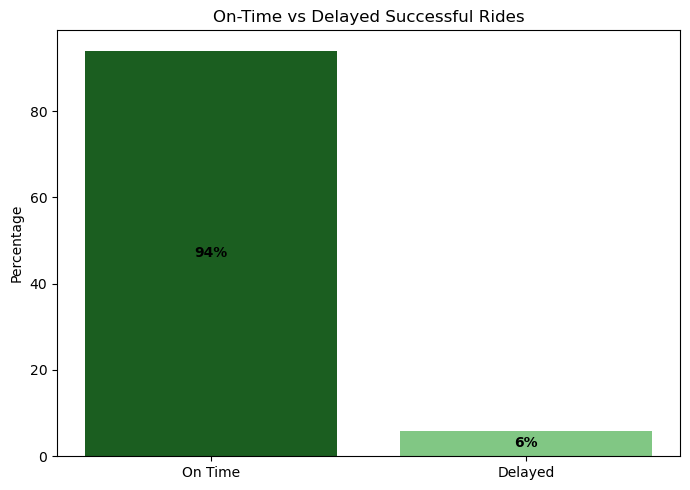

In [184]:
# Percentage of On-Time and Delayed successful rides

successful = df[df["Journey Status"].isin(["On Time", "Delayed"])]

on_time_pct = (successful["Journey Status"] == "On Time").mean() * 100
delayed_pct = (successful["Journey Status"] == "Delayed").mean() * 100

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["On Time", "Delayed"],
    [on_time_pct, delayed_pct],
    color=["#1B5E20", "#81C784"]
)

for bar, percentage in zip(bars, [on_time_pct, delayed_pct]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{percentage:.0f}%",
        ha="center",
        va="center",
        fontweight="bold"
    )

plt.title("On-Time vs Delayed Successful Rides")
plt.ylabel("Percentage")

plt.tight_layout()
plt.show()


In [185]:
#Out of Succesful rides only 6% are delayed.

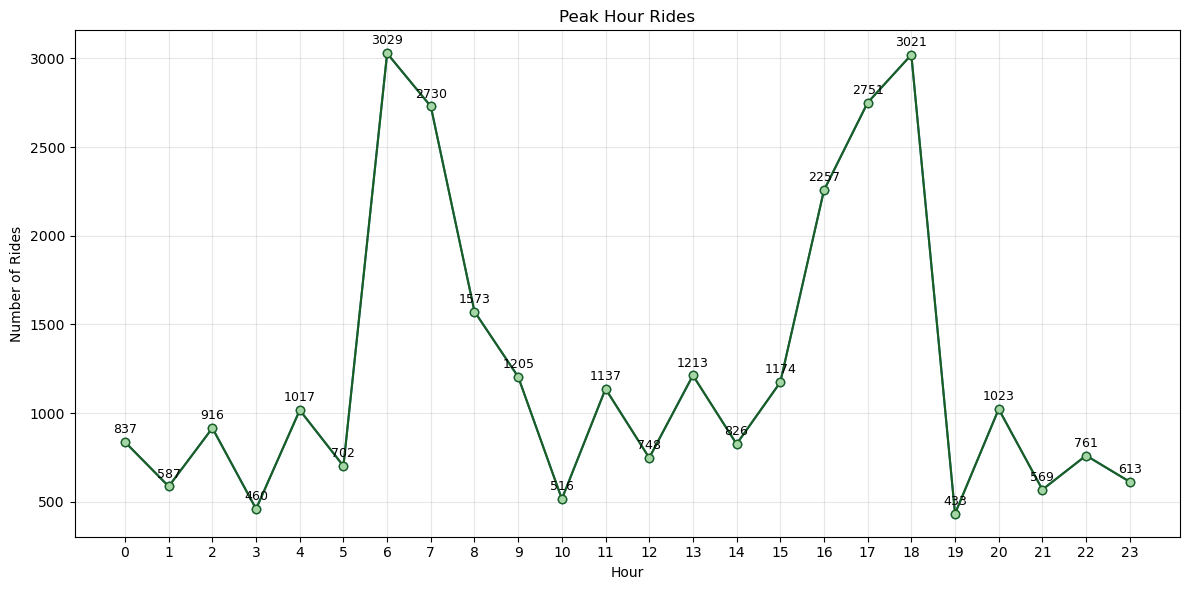

In [186]:
# Peak hour rides with number of rides shown on the graph

df["Departure Hour"] = pd.to_datetime(
    df["Departure Time"].astype(str)
).dt.hour

hourly_rides = df["Departure Hour"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_rides.index,
    hourly_rides.values,
    marker="o"
)

# Show number of rides on each point
for hour, rides in hourly_rides.items():
    plt.text(
        hour,
        rides + 50,
        str(rides),
        ha="center",
        fontsize=9
    )
plt.plot(
    hourly_rides.index,
    hourly_rides.values,
    color="#1B5E20", # Dark green line
    marker="o",
    markerfacecolor="#A5D6A7", # Light green dots
    markeredgecolor="#1B5E20"
)
plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.title("Peak Hour Rides")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [187]:
# Find the peak travel hours

print(hourly_rides.sort_values(ascending=False).head(5))


Departure Hour
6     3029
18    3021
17    2751
7     2730
16    2257
Name: count, dtype: int64


In [188]:
#Peak Travelling time is 6am and 6pm.

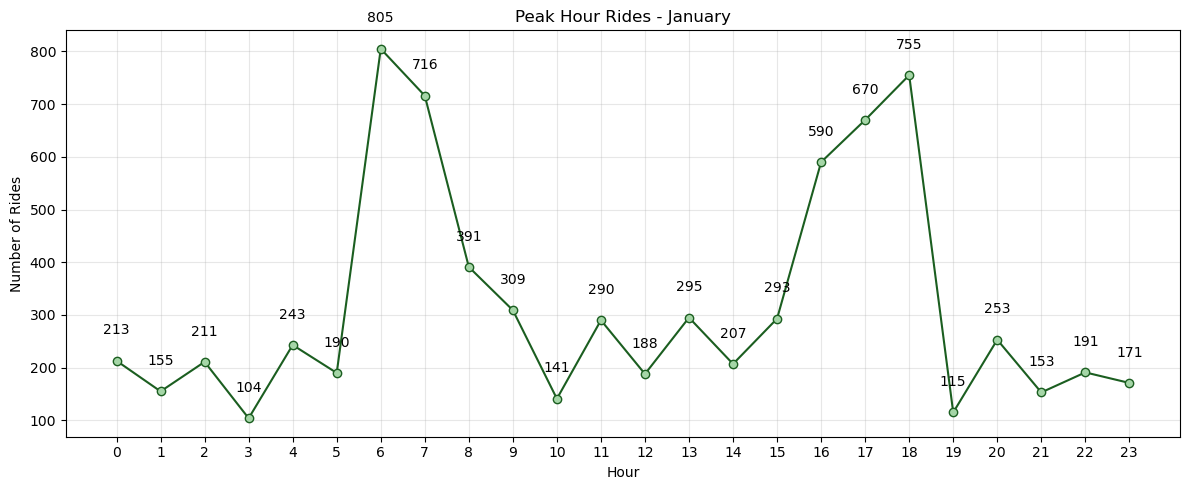

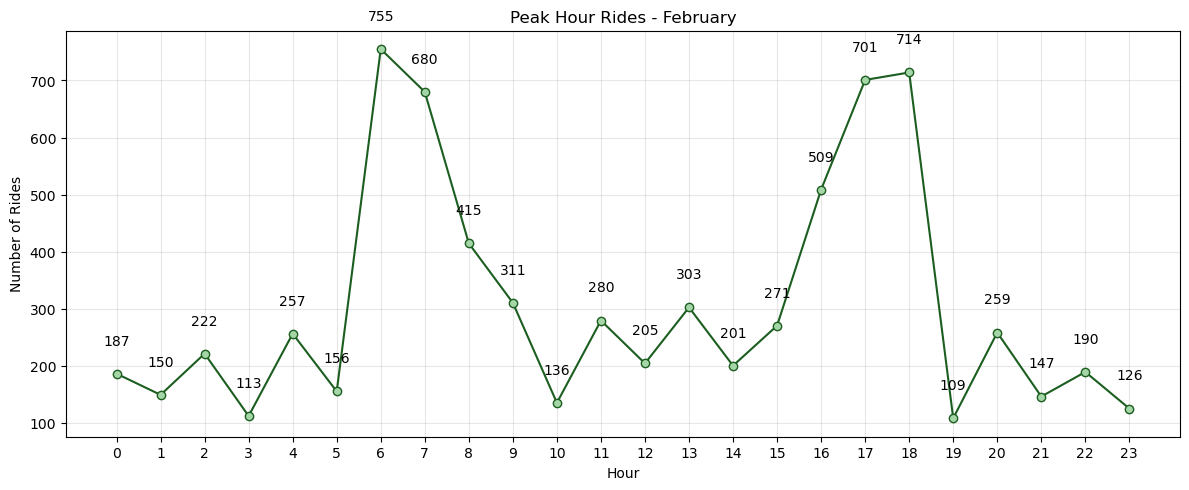

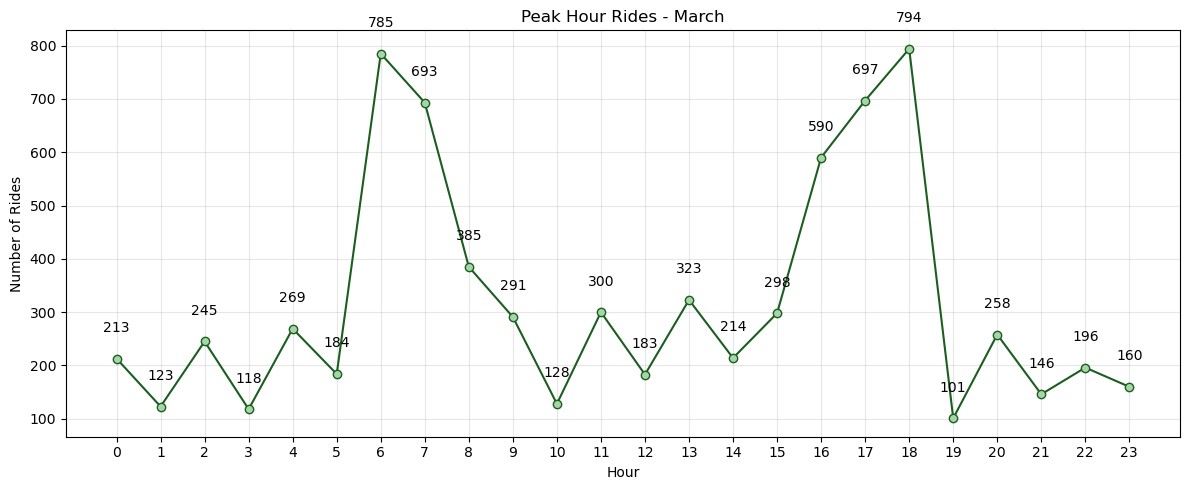

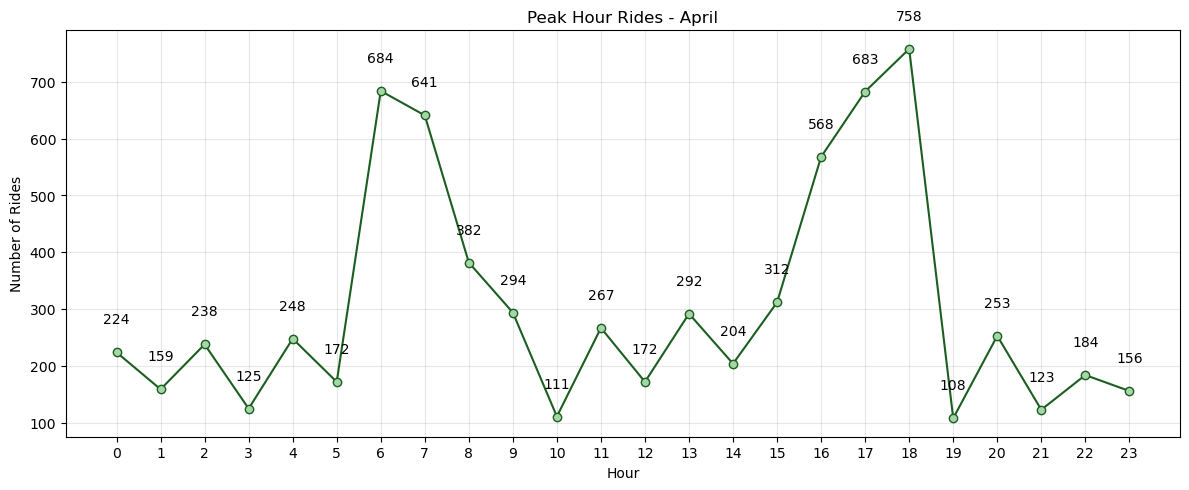

In [189]:
# Peak hour rides for each month

df["Departure Hour"] = pd.to_datetime(
    df["Departure Time"].astype(str)
).dt.hour

monthly_hourly = (
    df.groupby(["Month of Travel", "Departure Hour"])
    .size()
    .reset_index(name="Rides")
)

months = ["January", "February", "March", "April"]

for month in months:
    data = monthly_hourly[monthly_hourly["Month of Travel"] == month]

    plt.figure(figsize=(12, 5))
    
    plt.plot(
    data["Departure Hour"],
    data["Rides"],
    color="#1B5E20", # Dark green line
    marker="o",
    markerfacecolor="#A5D6A7", # Light green dots
    markeredgecolor="#1B5E20"
)
   
    # Show number of rides on each point
    for hour, rides in zip(data["Departure Hour"], data["Rides"]):
        plt.text(
            hour,
            rides + 50,
            str(rides),
            ha="center"
        )

    plt.title(f"Peak Hour Rides - {month}")
    plt.xlabel("Hour")
    plt.ylabel("Number of Rides")
    plt.xticks(range(24))
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [190]:
# Print the hour with the highest number of rides in each month

for month in ["January", "February", "March", "April"]:
    data = monthly_hourly[monthly_hourly["Month of Travel"] == month]
    
    peak = data.loc[data["Rides"].idxmax()]
    
    print(
        month,
        ":", 
        int(peak["Departure Hour"]),
        "hour -",
        int(peak["Rides"]),
        "rides"
    )


January : 6 hour - 805 rides
February : 6 hour - 755 rides
March : 18 hour - 794 rides
April : 18 hour - 758 rides


In [191]:
# On-time ride analysis by time period

df["Departure Hour"] = pd.to_datetime(
    df["Departure Time"].astype(str)
).dt.hour

def time_period(hour):
    if 0 <= hour <= 3:
        return "Early Morning (12AM - 3AM)"
    elif 4 <= hour <= 7:
        return "Morning (4AM - 7AM)"
    elif 8 <= hour <= 11:
        return "Late Morning (8AM - 11AM)"
    elif 12 <= hour <= 15:
        return "Afternoon (12PM - 3PM)"
    elif 16 <= hour <= 19:
        return "Evening (4PM - 7PM)"
    else:
        return "Night (8PM - 11PM)"

df["Time Period"] = df["Departure Hour"].apply(time_period)

on_time_percentage = (
    df.groupby("Time Period")["Journey Status"]
    .apply(lambda x: (x == "On Time").mean() * 100)
)

print(on_time_percentage)


Time Period
Afternoon (12PM - 3PM)        91.037617
Early Morning (12AM - 3AM)    92.107143
Evening (4PM - 7PM)           86.858899
Late Morning (8AM - 11AM)     76.213044
Morning (4AM - 7AM)           91.374699
Night (8PM - 11PM)            96.459879
Name: Journey Status, dtype: float64


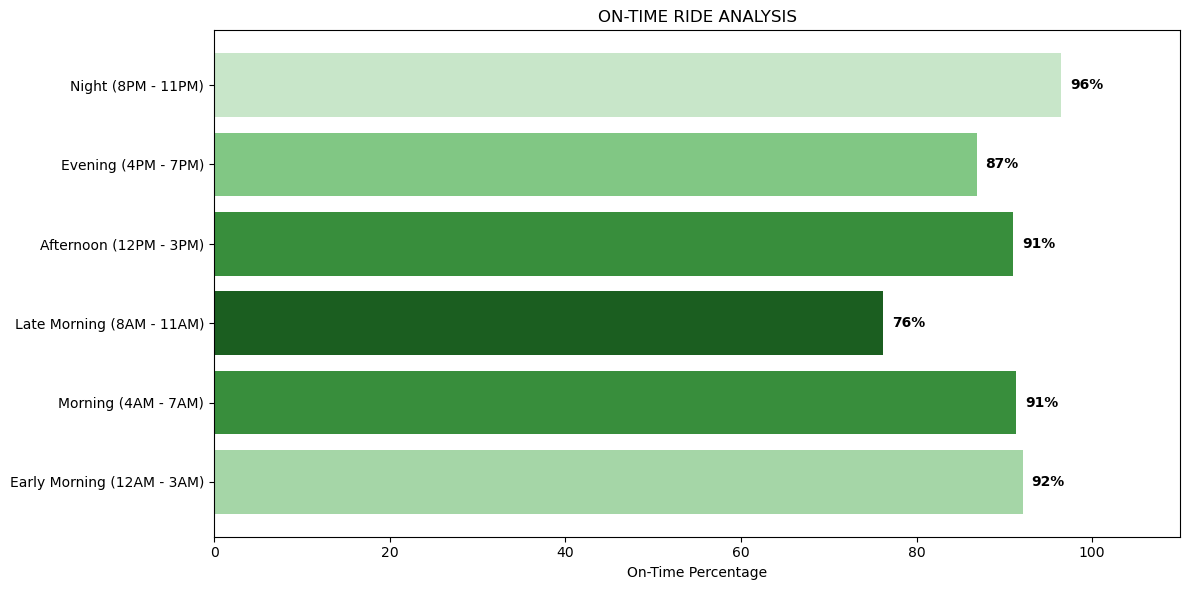

In [197]:
# Plot on-time percentage by time period

order = [
    "Early Morning (12AM - 3AM)",
    "Morning (4AM - 7AM)",
    "Late Morning (8AM - 11AM)",
    "Afternoon (12PM - 3PM)",
    "Evening (4PM - 7PM)",
    "Night (8PM - 11PM)"
]

data = on_time_percentage.reindex(order)

plt.figure(figsize=(12, 6))

bars = plt.barh(
    order,
    data,
    color=[
        "#A5D6A7",
        "#388E3C",
         "#1B5E20", "#388E3C", "#81C784",
        "#C8E6C9" ])
         
for bar, value in zip(bars, data):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}%",
        va="center",
        fontweight="bold"
    )

plt.xlabel("On-Time Percentage")
plt.title("ON-TIME RIDE ANALYSIS")
plt.xlim(0, 110)

plt.tight_layout()
plt.show()


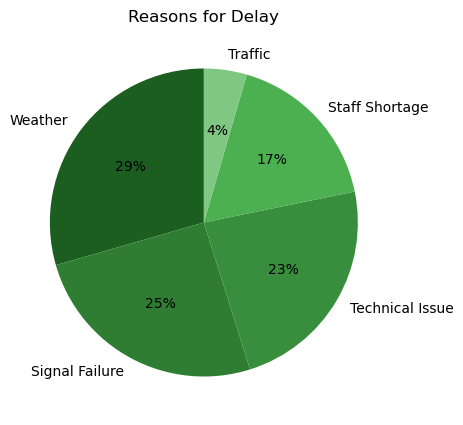

In [204]:
# Pie chart showing reasons for delayed rides

delayed = df[df["Journey Status"] == "Delayed"]

reason_counts = delayed["Reason for Delay"].value_counts()

plt.figure(figsize=(5,5))

colors = [
    "#1B5E20",
    "#2E7D32",
    "#388E3C",
    "#4CAF50",
    "#81C784",
    "#A5D6A7"
]
plt.pie(
    reason_counts,
    labels=reason_counts.index,
    autopct="%1.0f%%",
    startangle=90,
    colors=colors
)

plt.title("Reasons for Delay")
plt.show()


In [205]:
# Calculate revenue loss due to cancelled rides

cancelled = df[df["Journey Status"] == "Cancelled"]

revenue_loss = cancelled["Price"].sum()

print("Revenue loss due to cancellations:", revenue_loss)

# Cancellation reasons and revenue loss

cancelled = df[df["Journey Status"] == "Cancelled"]

cancellation_summary = cancelled.groupby("Reason for Delay").agg(
    Cancelled_Rides=("Transaction ID", "count"),
    Revenue_Loss=("Price", "sum")
)

print(cancellation_summary)




Revenue loss due to cancellations: 35066
                  Cancelled_Rides  Revenue_Loss
Reason for Delay                               
Signal Failure                492          9077
Staff Shortage                432          8258
Technical Issue               229          4245
Traffic                       222          4601
Weather                       427          8885


In [206]:
# Percentage of revenue loss due to cancelled rides

cancelled_revenue = df[df["Journey Status"] == "Cancelled"]["Price"].sum()
overall_revenue = df["Price"].sum()

loss_percentage = (cancelled_revenue / overall_revenue) * 100

print("Revenue loss due to cancellations:", cancelled_revenue)
print("Overall revenue:", overall_revenue)
print("Percentage of revenue loss:", loss_percentage, "%")


Revenue loss due to cancellations: 35066
Overall revenue: 553948
Percentage of revenue loss: 6.33019705820763 %


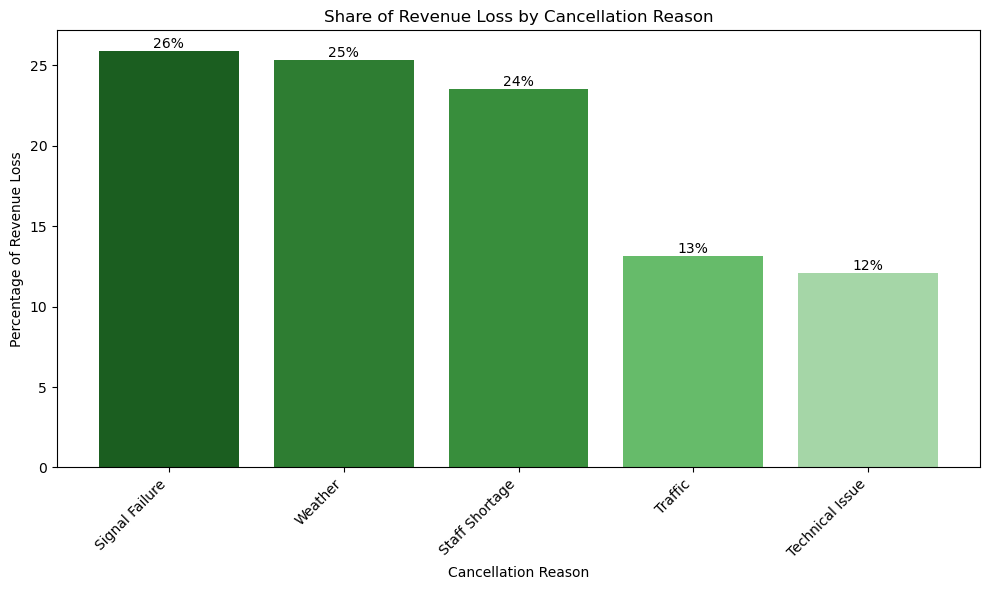

In [208]:
# Bar graph showing revenue loss due to cancelled rides by reason

cancelled = df[df["Journey Status"] == "Cancelled"]

revenue_loss = cancelled.groupby("Reason for Delay")["Price"].sum().sort_values(ascending=False)

percentage = (revenue_loss / revenue_loss.sum()) * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(revenue_loss.index, percentage,color=[
        "#1B5E20",
        "#2E7D32",
        "#388E3C",
        "#66BB6A",
        "#A5D6A7"
    ])

plt.title("Share of Revenue Loss by Cancellation Reason")
plt.xlabel("Cancellation Reason")
plt.ylabel("Percentage of Revenue Loss")

for bar, pct in zip(bars, percentage):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.0f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


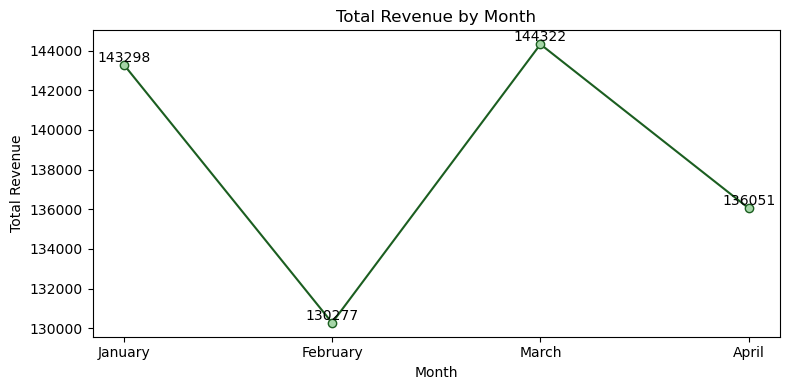

In [211]:
# Line graph showing total revenue in each month

monthly_revenue = df.groupby("Month of Travel")["Price"].sum()

monthly_revenue = monthly_revenue.reindex(
    ["January", "February", "March", "April"]
)

plt.figure(figsize=(8, 4))
plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    color="#1B5E20", # Dark green line
    marker="o",
    markerfacecolor="#A5D6A7", # Light green dots
    markeredgecolor="#1B5E20"
)

# Show revenue values on the graph
for month, revenue in monthly_revenue.items():
    plt.text(month, revenue, f"{revenue:.0f}", ha="center", va="bottom")

plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()


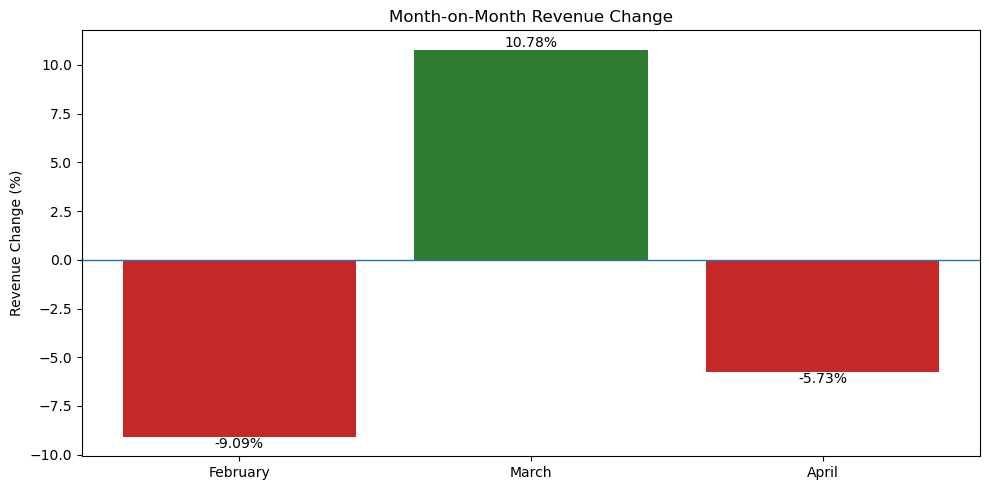

In [212]:
# Month-on-Month Revenue Change

monthly_revenue = df.groupby("Month of Travel")["Price"].sum()

monthly_revenue = monthly_revenue.reindex(
    ["January", "February", "March", "April"]
)

mom_change = monthly_revenue.pct_change() * 100

months = ["February", "March", "April"]
changes = mom_change.loc[months]

plt.figure(figsize=(10, 5))

colors = ["#C62828" if value < 0 else "#2E7D32" for value in changes]

bars = plt.bar(months, changes, color=colors)

for bar, value in zip(bars, changes):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.axhline(0, linewidth=1)
plt.title("Month-on-Month Revenue Change")
plt.ylabel("Revenue Change (%)")

plt.tight_layout()
plt.show()


In [ ]:
#Revenue increased 10.78% in March.